# VQCFD Results Analysis

The reusable logic lives in `analysis.py`. This notebook only contains run selections and plotting options.


In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis as an

an.configure_plots()
RESULTS_ROOT = an.RESULTS_ROOT
RESULTS_ROOT


PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results')

## Discover saved runs


In [2]:
# Each filter accepts one value, a list of values, or None for every value.
NS = [2,3,4]                # e.g. 3 or [2, 3, 4]
LS = None                 # e.g. 2 or [1, 2, 3]
CIRCUITS = "default" #["all_to_all_crx","block_crx","ring_trainable_crz","ghz_orbit","local_ry_rz"]           # e.g. "multiscale_tree" or ["default", "uni2"]
INITIAL_STATES = None     # e.g. "sine" or ["sine", "tapered_gaussian"]
MODES = "gradient"              # e.g. "noise_free" or ["variance", "gradient"]

runs = an.list_runs(
    ns=NS,
    ls=LS,
    circuits=CIRCUITS,
    initial_states=INITIAL_STATES,
    modes=MODES,
)
an.print_runs(runs)


 N  L Circuit          Initial state     Mode  Parameters  Saved  Variance
 2  1 default                   sine gradient           4  False     False
 2  1 default       mixed_sine_modes gradient           4  False     False
 2  1 default positive_periodic_wave gradient           4  False     False
 2  1 default       tapered_gaussian gradient           4  False     False
 2  2 default                   sine gradient           6  False     False
 2  2 default       mixed_sine_modes gradient           6  False     False
 2  2 default positive_periodic_wave gradient           6  False     False
 2  2 default       tapered_gaussian gradient           6  False     False
 2  4 default                   sine gradient          10  False     False
 2  4 default       mixed_sine_modes gradient          10  False     False
 2  4 default positive_periodic_wave gradient          10  False     False
 2  4 default       tapered_gaussian gradient          10  False     False
 2  8 default            

In [248]:
# Optional filters: n=..., l=...
preset_rows = an.list_initial_param_presets(n = 6, circuit="multiscale_tree", show_variants=False)


N=6, L=1 | default_len=13 | default_mse=0.026308669655778574
N=6, L=2 | default_len=19 | default_mse=0.00034216808447705345
N=6, L=3 | default_len=25 | default_mse=0.00022093751229731567
N=6, L=4 | default_len=31 | default_mse=1.4132765958221204e-06
N=6, L=5 | default_len=37 | default_mse=2.6986324565342634e-06
N=6, L=6 | default_len=43 | default_mse=1.5119335353666355e-06
N=6, L=7 | default_len=49 | default_mse=1.4055003835099423e-07
N=6, L=8 | default_len=55 | default_mse=5.47238702094108e-07
count=8 presets


## Inspect one run


In [106]:
DIR_LABEL = "N3_default_rzrxrz"
LABEL = "L2"

run = an.load_run(DIR_LABEL, LABEL)
run


RunData(dir_label='N3_default_rzrxrz', label='L2', full_label='N3_default_rzrxrz_L2', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N3_default_rzrxrz'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N3_default_rzrxrz/data_L2'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_N3_default_rzrxrz/figures_L2'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': False, 'contraction_path_cache_dir': '.contraction_paths', 'contraction_path_max_time_s': 600.0, 'contraction_path_methods': ['greedy', 'kahypar'], 'contraction_path_objective': 'combo', 'contraction_path_repeats': 256, 'contraction_path_reuse_saved': True, 'contraction_path_seed': 0, 'contraction_path_simplify_sequence': 'RC', 'data_dir': 'results/results_N3_default_rzrxrz/data_L2', 'dir_label': 'N3_default_rzrxrz', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_N3_defaul

In [3]:
print("manifest path:", run.files["manifest"])
print("values yaml path:", run.files["values_yaml"])
print("values keys:", list(run.values.keys()))
run.values


manifest path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_tests/manifest_tests_N3_L2.yaml
values yaml path: /Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_tests/data_N3_L2/values_tests_N3_L2.yaml
values keys: ['n', 'l', 'shots', 'max_iter', 't_total', 'mu', 'dt', 'plat_tol', 'patience', 'unitary_circuit', 'initial_state', 'number_of_parameters', 'number_of_optimization_parameters', 'initial_params_source', 'contraction_paths', 'initial_fit_mse', 'shots_used_per_timestep', 'shots_used_total']


{'n': 3,
 'l': 2,
 'shots': 100,
 'max_iter': 100,
 't_total': 0.29,
 'mu': 0.01,
 'dt': 0.01,
 'plat_tol': 0.00015,
 'patience': 15,
 'unitary_circuit': 'default',
 'initial_state': 'sine',
 'number_of_parameters': 9,
 'number_of_optimization_parameters': 10,
 'initial_params_source': 'preset',
 'contraction_paths': {'kind': 'local_expectations',
  'source': 'searched',
  'simplify_sequence': 'RC',
  'search_time_s': 241.64041558299505,
  'prepare_time_s': 241.6504936249985,
  'cache_path': '.contraction_paths/local_expectations_N3_L2_default_simplify-RC.yaml',
  'networks': [{'label': 'c1',
    'trials': 256,
    'methods_sampled': {'greedy': 54, 'kahypar': 202},
    'num_tensors': 69,
    'path_length': 68,
    'contraction_width': 4.0,
    'log10_flops': 3.547528576459782,
    'max_size': 16,
    'peak_size': 768,
    'total_write': 1049,
    'combo_cost': 70664.0},
   {'label': 'c2',
    'trials': 256,
    'methods_sampled': {'greedy': 35, 'kahypar': 221},
    'num_tensors': 81,
 

In [17]:
costs = run.costs
times = run.times
params = run.params
variance = run.variance

print("costs:", None if costs is None else costs.shape)
print("times:", None if times is None else times.shape)
print("params:", None if params is None else params.shape)
print("variance:", variance)


costs: (28,)
times: (28,)
params: (29, 21)
variance: None


In [18]:
cost_histories = an.load_per_timestep_histories(run, "cost_iter")
param_histories = an.load_per_timestep_histories(run, "params_iter")
print("cost_iter timesteps:", len(cost_histories))
print("params_iter timesteps:", len(param_histories))


cost_iter timesteps: 28
params_iter timesteps: 0


In [ ]:
COST_TIME_FIGSIZE = (12, 4)
an.plot_costs_and_times(run, figsize=COST_TIME_FIGSIZE);


## Cost evolution within an optimization timestep

Every evolved timestep has its optimizer cost evaluations saved in a separate `cost_iter` file. Add one or more `(directory, label)` pairs to `COST_RUN_SELECTION`. The same `COST_TIMESTEPS` selection is applied independently to every run: use one integer for a single timestep, a list such as `[0, 5, 10]` to overlay several timesteps, `None` for every saved timestep, or `-1` for each run's final saved timestep. `COST_ALPHA` controls how transparent overlapping traces are. The remaining options mirror the configurable general plots.

All processing options below are **off by default**. For the large early peak, use `COST_EXCLUDE_ITERATIONS = [1]` to remove only the second cost value; because the original iteration numbers remain on the x-axis, a line plot connects iteration 0 directly to iteration 2. `COST_ITERATION_SLICE = slice(2, None)` is the Python equivalent of keeping `[2:]`. Other opt-in choices are per-trace outlier masking or clipping, normalization, a best-so-far convergence curve, and rolling mean/median smoothing. `COST_Y_PERCENTILE_LIMITS` only zooms the displayed y-range and never changes the plotted data.

Normalization methods are `"start_end"` (first visible value maps to 1 and final visible value to 0), `"initial"` (divide by the first visible value), `"minmax"`, and `"zscore"`. When several transformations are enabled, they are applied in this order: slice, explicit iteration exclusion, outliers, running best, normalization, smoothing.

`COST_LABEL_BY` can be `"auto"`, `"run"`, `"timestep"`, `"run_timestep"`, `"expressibility"`, `"expressibility_timestep"`, or `"none"`. Expressibility labels use the saved KL divergence, for which lower values mean greater expressibility. Set `COST_SHOW_FIRST_N_LABELS = None` to label every trace, or `0` to hide the legend. Custom `COST_SERIES_LABELS` still take priority and must contain one label per plotted trace, ordered by run and then timestep.


N4_brickwork_ring_ry_L8: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
N4_L8: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
N4_multiscale_tree_L8: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
N4_paper_viscid_L6: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
N4_mps_staircase_light_L2: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


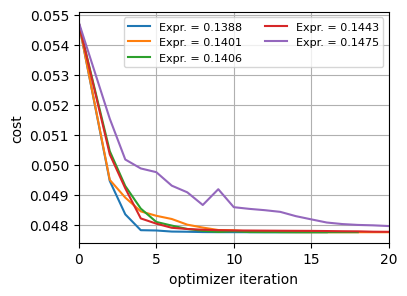

In [124]:
COST_RUN_SELECTION = [
    # ("N4_brickwork_ring_ry","L4"),
    # ("N4", "L4"),
    # ("N4_multiscale_tree","L4"),
    # ("N4_paper_viscid", "L3"),
    # # ("N4_mps_staircase_light","L1"),
    # ("N5_brickwork_ring_ry","L8"),
    # ("N5", "L8"),
    # # ("N5_multiscale_tree","L8"),
    # ("N5_paper_viscid", "L6"),
    # ("N5_mps_staircase_light","L2"),
    ("N4_brickwork_ring_ry","L8"),
    ("N4", "L8"),
    ("N4_multiscale_tree","L8"),
    ("N4_paper_viscid", "L6"),
    ("N4_mps_staircase_light","L2"),
]
COST_TIMESTEPS = [1] #[0,5,10,15,20,25]       # int, list of ints, None for all, or -1 for final

# Optional data transformations (all off by default)
COST_ITERATION_SLICE =  slice(0,None)        # e.g. slice(2, None), slice(2, 200), or (2, None)
COST_EXCLUDE_ITERATIONS = [1]          # e.g. [1] removes only the second value and joins 0 to 2
COST_NORMALIZE = False
COST_NORMALIZATION_METHOD = "minmax"  # start_end, initial, minmax, or zscore
COST_REMOVE_OUTLIERS = False
COST_OUTLIER_METHOD = "percentile"       # "iqr" or "percentile"
COST_OUTLIER_FACTOR = 1.5            # standard Tukey IQR multiplier
COST_OUTLIER_PERCENTILES = (0., 99.0)
COST_OUTLIER_ACTION = "mask"      # "mask" leaves gaps; "clip" keeps a continuous line
COST_RUNNING_BEST = False           # best-so-far cost, useful for optimizer convergence
COST_SMOOTHING_WINDOW = None        # e.g. 9; None disables smoothing
COST_SMOOTHING_METHOD = "median"  # "median" is robust to spikes; or "mean"
COST_SMOOTHING_CENTERED = True
COST_Y_PERCENTILE_LIMITS = None#(0., 98.0)     # e.g. (1, 99); view-only zoom, does not alter data

# Plot appearance
COST_ALPHA = 1.                    # 0 is transparent, 1 is opaque
COST_PLOT_KIND = "line"            # "line" or "scatter"
COST_LOG_Y = False
COST_X_LABEL = None                  # None uses "optimizer iteration"
COST_Y_LABEL = None                  # None uses the normalized/raw default
COST_TITLE = ""                    # None uses the run label
COST_LABEL_BY = "expressibility"             # use "expressibility" for saved KL-divergence labels
COST_EXPRESSIBILITY_LABEL_PRECISION = 4
COST_SERIES_LABELS = None            # optional custom label for every plotted trace
COST_SHOW_FIRST_N_LABELS = None        # None labels all traces; 0 hides the legend
COST_SHOW_FINAL_ERROR_METRICS = False  # final target/encoded L2 box at upper right
COST_X_LIMITS = (0,20)                 # e.g. (0, 250)
COST_Y_LIMITS = None#(0.051,0.0545)                 # e.g. (0, 0.01)
COST_FIGSIZE = (4, 3)                # width, height in inches

cost_runs = an.load_runs(COST_RUN_SELECTION)
for cost_run in cost_runs:
    available_cost_timesteps = [
        timestep
        for timestep, _ in an.load_per_timestep_histories(cost_run, "cost_iter")
    ]
    print(f"{cost_run.full_label}: {available_cost_timesteps}")
cost_fig, cost_ax = an.plot_cost_histories(
    cost_runs,
    timesteps=COST_TIMESTEPS,
    iteration_slice=COST_ITERATION_SLICE,
    exclude_iterations=COST_EXCLUDE_ITERATIONS,
    normalize=COST_NORMALIZE,
    normalization_method=COST_NORMALIZATION_METHOD,
    remove_outliers=COST_REMOVE_OUTLIERS,
    outlier_method=COST_OUTLIER_METHOD,
    outlier_factor=COST_OUTLIER_FACTOR,
    outlier_percentiles=COST_OUTLIER_PERCENTILES,
    outlier_action=COST_OUTLIER_ACTION,
    running_best=COST_RUNNING_BEST,
    smoothing_window=COST_SMOOTHING_WINDOW,
    smoothing_method=COST_SMOOTHING_METHOD,
    smoothing_centered=COST_SMOOTHING_CENTERED,
    show_first_n_labels=COST_SHOW_FIRST_N_LABELS,
    label_by=COST_LABEL_BY,
    expressibility_label_precision=COST_EXPRESSIBILITY_LABEL_PRECISION,
    show_final_error_metrics=COST_SHOW_FINAL_ERROR_METRICS,
    alpha=COST_ALPHA,
    kind=COST_PLOT_KIND,
    log_y=COST_LOG_Y,
    x_label=COST_X_LABEL,
    y_label=COST_Y_LABEL,
    title=COST_TITLE,
    series_labels=COST_SERIES_LABELS,
    x_limits=COST_X_LIMITS,
    y_limits=COST_Y_LIMITS,
    y_percentile_limits=COST_Y_PERCENTILE_LIMITS,
    figsize=COST_FIGSIZE,
)


In [109]:
cost_fig.savefig(f"figures/iterations/cost_vs_iter_N4.pdf", bbox_inches="tight")

N4_brickwork_ring_ry_L8_tapered_gaussian: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
N4_L8_tapered_gaussian: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
N4_multiscale_tree_L8_tapered_gaussian: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
N4_mps_staircase_light_L2_tapered_gaussian: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]


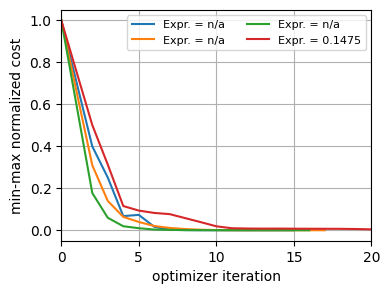

In [129]:
COST_RUN_SELECTION = [
    # ("N4_brickwork_ring_ry","L4_tapered_gaussian"),
    # ("N4", "L4_tapered_gaussian"),
    # ("N4_multiscale_tree","L4_tapered_gaussian"),
    # ("N4_paper_viscid", "L3_tapered_gaussian"),
    # # ("N4_mps_staircase_light","L1_tapered_gaussian"),
    # ("N5_brickwork_ring_ry","L8_tapered_gaussian"),
    # ("N5", "L8_tapered_gaussian"),
    # # ("N5_multiscale_tree","L8_tapered_gaussian"),
    # ("N5_paper_viscid", "L6_tapered_gaussian"),
    # ("N5_mps_staircase_light","L2_tapered_gaussian"),
    ("N4_brickwork_ring_ry","L8_tapered_gaussian"),
    ("N4", "L8_tapered_gaussian"),
    ("N4_multiscale_tree","L8_tapered_gaussian"),
    # ("N4_paper_viscid", "L6_tapered_gaussian"),
    ("N4_mps_staircase_light","L2_tapered_gaussian"),
]
COST_TIMESTEPS = [1] #[0,5,10,15,20,25]       # int, list of ints, None for all, or -1 for final

# Optional data transformations (all off by default)
COST_ITERATION_SLICE =  slice(0,None)        # e.g. slice(2, None), slice(2, 200), or (2, None)
COST_EXCLUDE_ITERATIONS = [1]          # e.g. [1] removes only the second value and joins 0 to 2
COST_NORMALIZE = True
COST_NORMALIZATION_METHOD = "minmax"  # start_end, initial, minmax, or zscore
COST_REMOVE_OUTLIERS = False
COST_OUTLIER_METHOD = "percentile"       # "iqr" or "percentile"
COST_OUTLIER_FACTOR = 1.5            # standard Tukey IQR multiplier
COST_OUTLIER_PERCENTILES = (0., 99.0)
COST_OUTLIER_ACTION = "mask"      # "mask" leaves gaps; "clip" keeps a continuous line
COST_RUNNING_BEST = False           # best-so-far cost, useful for optimizer convergence
COST_SMOOTHING_WINDOW = None        # e.g. 9; None disables smoothing
COST_SMOOTHING_METHOD = "median"  # "median" is robust to spikes; or "mean"
COST_SMOOTHING_CENTERED = True
COST_Y_PERCENTILE_LIMITS = None#(0., 98.0)     # e.g. (1, 99); view-only zoom, does not alter data

# Plot appearance
COST_ALPHA = 1.                    # 0 is transparent, 1 is opaque
COST_PLOT_KIND = "line"            # "line" or "scatter"
COST_LOG_Y = False
COST_X_LABEL = None                  # None uses "optimizer iteration"
COST_Y_LABEL = None                  # None uses the normalized/raw default
COST_TITLE = ""                    # None uses the run label
COST_LABEL_BY = "expressibility"             # use "expressibility" for saved KL-divergence labels
COST_EXPRESSIBILITY_LABEL_PRECISION = 4
COST_SERIES_LABELS = None            # optional custom label for every plotted trace
COST_SHOW_FIRST_N_LABELS = None        # None labels all traces; 0 hides the legend
COST_SHOW_FINAL_ERROR_METRICS = False  # final target/encoded L2 box at upper right
COST_X_LIMITS = (0,20)                 # e.g. (0, 250)
COST_Y_LIMITS = None#(0.051,0.0545)                 # e.g. (0, 0.01)
COST_FIGSIZE = (4, 3)                # width, height in inches

cost_runs = an.load_runs(COST_RUN_SELECTION)
for cost_run in cost_runs:
    available_cost_timesteps = [
        timestep
        for timestep, _ in an.load_per_timestep_histories(cost_run, "cost_iter")
    ]
    print(f"{cost_run.full_label}: {available_cost_timesteps}")
cost_fig, cost_ax = an.plot_cost_histories(
    cost_runs,
    timesteps=COST_TIMESTEPS,
    iteration_slice=COST_ITERATION_SLICE,
    exclude_iterations=COST_EXCLUDE_ITERATIONS,
    normalize=COST_NORMALIZE,
    normalization_method=COST_NORMALIZATION_METHOD,
    remove_outliers=COST_REMOVE_OUTLIERS,
    outlier_method=COST_OUTLIER_METHOD,
    outlier_factor=COST_OUTLIER_FACTOR,
    outlier_percentiles=COST_OUTLIER_PERCENTILES,
    outlier_action=COST_OUTLIER_ACTION,
    running_best=COST_RUNNING_BEST,
    smoothing_window=COST_SMOOTHING_WINDOW,
    smoothing_method=COST_SMOOTHING_METHOD,
    smoothing_centered=COST_SMOOTHING_CENTERED,
    show_first_n_labels=COST_SHOW_FIRST_N_LABELS,
    label_by=COST_LABEL_BY,
    expressibility_label_precision=COST_EXPRESSIBILITY_LABEL_PRECISION,
    show_final_error_metrics=COST_SHOW_FINAL_ERROR_METRICS,
    alpha=COST_ALPHA,
    kind=COST_PLOT_KIND,
    log_y=COST_LOG_Y,
    x_label=COST_X_LABEL,
    y_label=COST_Y_LABEL,
    title=COST_TITLE,
    series_labels=COST_SERIES_LABELS,
    x_limits=COST_X_LIMITS,
    y_limits=COST_Y_LIMITS,
    y_percentile_limits=COST_Y_PERCENTILE_LIMITS,
    figsize=COST_FIGSIZE,
)

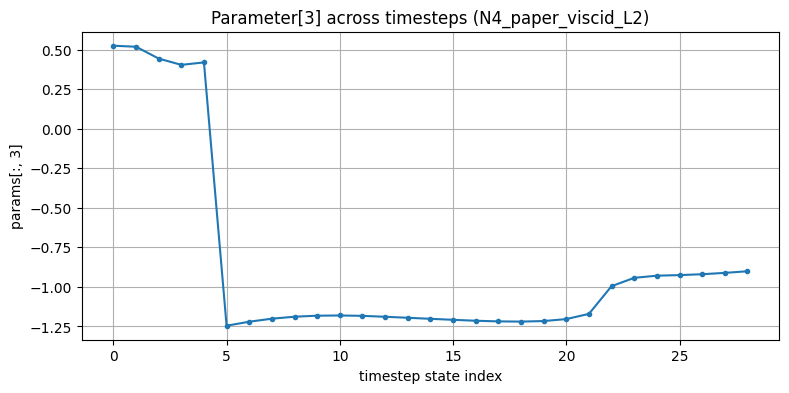

In [105]:
PARAMETER_FIGSIZE = (9, 4)
an.plot_parameter_history(cost_run, parameter_index=3, figsize=PARAMETER_FIGSIZE);


shots_used_total: 0


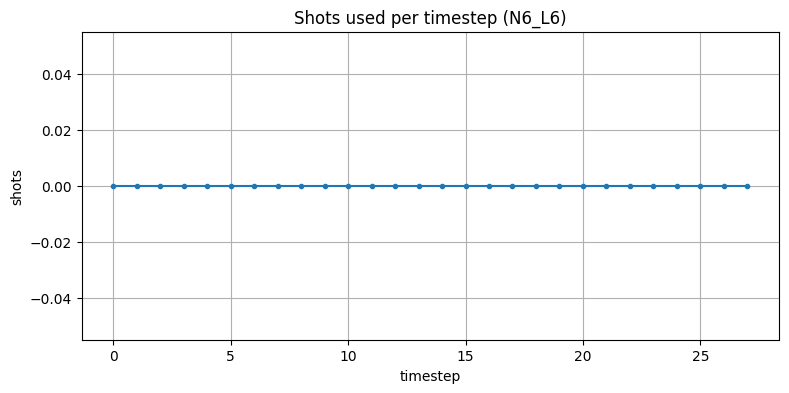

In [40]:
SHOTS_FIGSIZE = (9, 4)
an.plot_shots(cost_run, figsize=SHOTS_FIGSIZE);

## Classical and quantum fields at one timestep

Use `TIMESTEP = 0` for the initial state, a positive saved-state index, or `-1` for the final state. The plot reports MSE, R², and normalized squared-overlap fidelity.


In [15]:
DIR_LABEL = "tests"
LABEL = "N3L2_paper_viscid"

run = an.load_run(DIR_LABEL, LABEL)
run

RunData(dir_label='tests', label='N3L2_paper_viscid', full_label='tests_N3L2_paper_viscid', results_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_tests'), data_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_tests/data_N3L2_paper_viscid'), fig_dir=PosixPath('/Users/joel/Documents/MA/Code/VQCFD_quimb/results/results_tests/figures_N3L2_paper_viscid'), manifest={'cobyla_maxiter': 100000, 'cobyla_tol': 1e-05, 'compute_expr_cap': False, 'contraction_path_cache_dir': '.contraction_paths', 'contraction_path_max_time_s': 600.0, 'contraction_path_methods': ['greedy', 'kahypar'], 'contraction_path_objective': 'combo', 'contraction_path_repeats': 256, 'contraction_path_reuse_saved': True, 'contraction_path_seed': 0, 'contraction_path_simplify_sequence': 'RC', 'data_dir': 'results/results_tests/data_N3L2_paper_viscid', 'dir_label': 'tests', 'dt': 0.01, 'expr_bins': 100, 'expr_entcap_samples': 100000, 'fig_dir': 'results/results_tests/figures_N3L2

timestep                       28.000000
time                            0.280000
MSE                             0.000001
R2                              0.999999
Fidelity                        0.999999
RelativeL1Error                 0.001379
RelativeL2Error                 0.001158
RelativeLinfError               0.000934
RelativeDerivativeL2Error       0.001277
RelativeDerivativeLinfError     0.001001
RelativeMassError                    NaN
NormalizedMassDrift             0.537635
dtype: float64

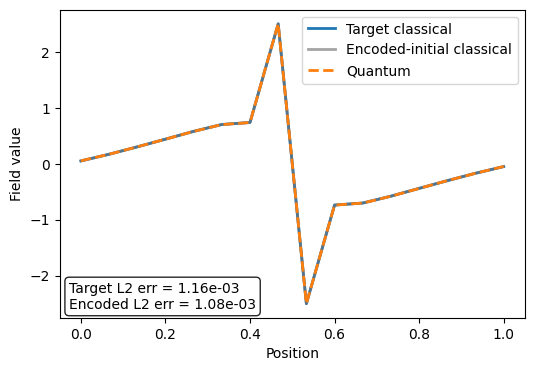

In [109]:
DIR_LABEL = "N4_default_rzrxrz"
LABEL = "L3"

run = an.load_run(DIR_LABEL, LABEL)

TIMESTEP = -1
TIMESTEP_FIGSIZE = (6, 4)

timestep_comparison, ax, fig = an.plot_run_timestep_comparison(
    run, timestep=TIMESTEP, figsize=TIMESTEP_FIGSIZE
)
TIMESTEP_METRICS = [
    "timestep", "time", "MSE", "R2", "Fidelity",
    "RelativeL1Error", "RelativeL2Error", "RelativeLinfError",
    "RelativeDerivativeL2Error", "RelativeDerivativeLinfError",
    "RelativeMassError", "NormalizedMassDrift",
]
pd.Series({key: timestep_comparison[key] for key in TIMESTEP_METRICS})


In [ ]:
# fig.savefig(f"figures/single_runs/single_run_{DIR_LABEL}_{LABEL}.pdf", bbox_inches='tight')

timestep                       2.800000e+01
time                           2.800000e-01
MSE                            3.911726e-07
R2                             9.999996e-01
Fidelity                       9.999996e-01
RelativeL1Error                6.654247e-04
RelativeL2Error                6.272321e-04
RelativeLinfError              7.830627e-04
RelativeDerivativeL2Error      7.266467e-04
RelativeDerivativeLinfError    6.785426e-04
RelativeMassError                       NaN
NormalizedMassDrift            3.440001e-01
dtype: float64

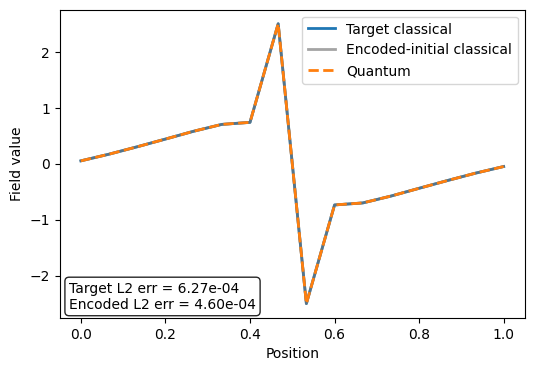

In [110]:
DIR_LABEL = "N4"
LABEL = "L3"

run = an.load_run(DIR_LABEL, LABEL)
TIMESTEP = -1
TIMESTEP_FIGSIZE = (6, 4)

timestep_comparison, ax, fig = an.plot_run_timestep_comparison(
    run, timestep=TIMESTEP, figsize=TIMESTEP_FIGSIZE
)
TIMESTEP_METRICS = [
    "timestep", "time", "MSE", "R2", "Fidelity",
    "RelativeL1Error", "RelativeL2Error", "RelativeLinfError",
    "RelativeDerivativeL2Error", "RelativeDerivativeLinfError",
    "RelativeMassError", "NormalizedMassDrift",
]
pd.Series({key: timestep_comparison[key] for key in TIMESTEP_METRICS})

# fig.savefig(f"figures/single_runs/single_run_{DIR_LABEL}_{LABEL}.pdf", bbox_inches='tight')

## Classical and quantum fields over the whole time evolution

Choose `EVOLUTION_FIELDS = "classical"`, `"quantum"`, or `"both"`. Increase `TIMESTEP_STRIDE` to show fewer saved timesteps.


In [ ]:
EVOLUTION_FIELDS = "both"       # "classical", "quantum", or "both"
TIMESTEP_STRIDE = 1             # 1 plots every saved timestep
EVOLUTION_FIGSIZE = (10, 7)

evolution, evolution_ax, evolution_fig = an.plot_run_time_evolution(
    run,
    fields=EVOLUTION_FIELDS,
    timestep_stride=TIMESTEP_STRIDE,
    figsize=EVOLUTION_FIGSIZE,
)


In [ ]:
# evolution_fig.savefig(f"figures/single_runs/single_run_evolution_{DIR_LABEL}_{LABEL}_{EVOLUTION_FIELDS}_{TIMESTEP_STRIDE}.pdf", bbox_inches='tight')

## Evolution-error diagnostics

These plots use the currently selected `run`. The first figure shows the total end-to-end L2 error, the evolution error relative to the encoded-initial classical trajectory, the propagated initial-fit error, derivative and maximum-point errors, and the alignment between the two L2 error vectors. Negative alignment indicates partial error cancellation. The second figure compares the three fields and their signed residuals at `ERROR_TIMESTEP`.


,Timestep,Time,RelativeL2Error,EvolutionRelativeL2Error,PropagatedInitialRelativeL2Error,RelativeDerivativeL2Error,RelativeLinfError,ErrorAlignmentCosine
24,24,0.24,0.000713,0.000581,0.000590,0.000819,0.000913,-0.260266
25,25,0.25,0.000803,0.000664,0.000548,0.000947,0.000878,-0.131482
26,26,0.26,0.000748,0.000539,0.000493,0.000864,0.000892,0.048315
27,27,0.27,0.000695,0.000487,0.000429,0.000794,0.000842,0.147227
28,28,0.28,0.000627,0.000460,0.000360,0.000727,0.000783,0.157425


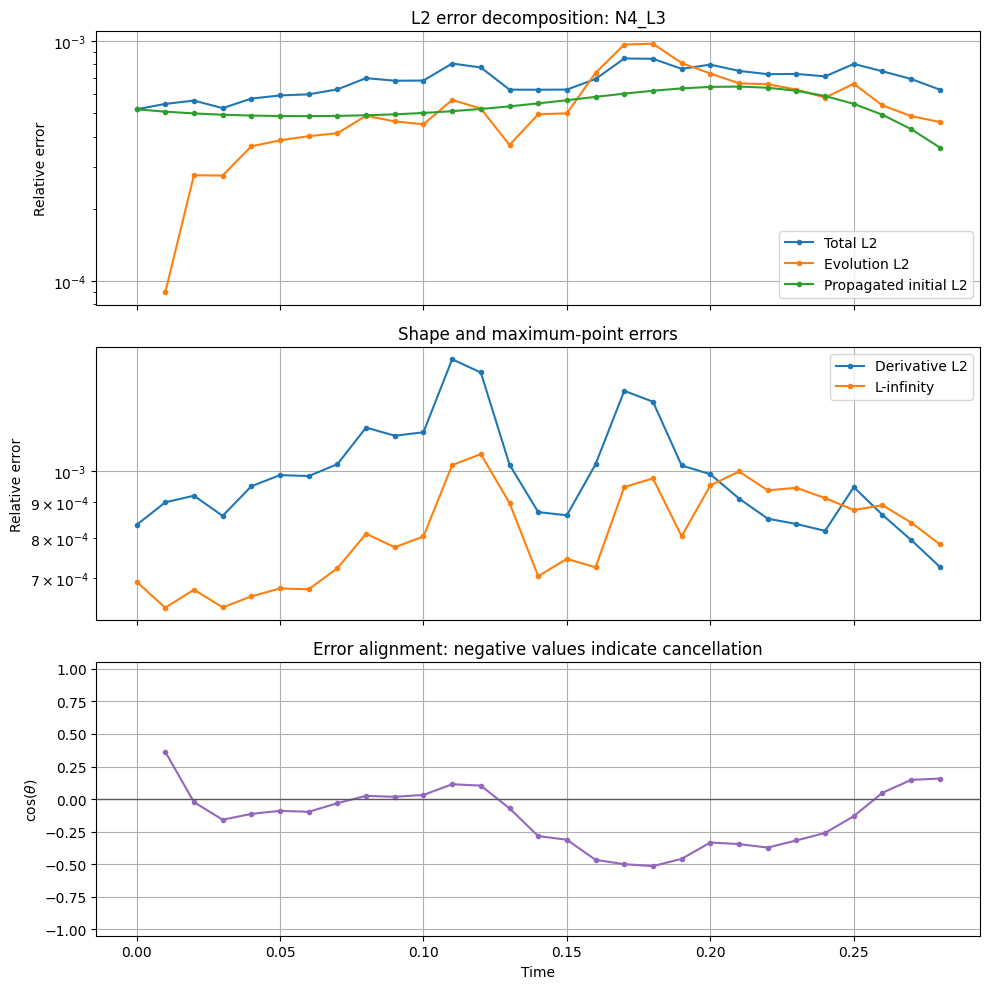

In [152]:
ERROR_LOG_SCALE = True
ERROR_EVOLUTION_FIGSIZE = (10, 10)

error_diagnostics, error_axes, error_fig = an.plot_evolution_error_diagnostics(
    run,
    log_error_y=ERROR_LOG_SCALE,
    figsize=ERROR_EVOLUTION_FIGSIZE,
)
error_diagnostics.tail()


timestep                            28.000000
time                                 0.280000
RelativeL2Error                      0.000627
EvolutionRelativeL2Error             0.000460
PropagatedInitialRelativeL2Error     0.000360
RelativeDerivativeL2Error            0.000727
RelativeLinfError                    0.000783
dtype: float64

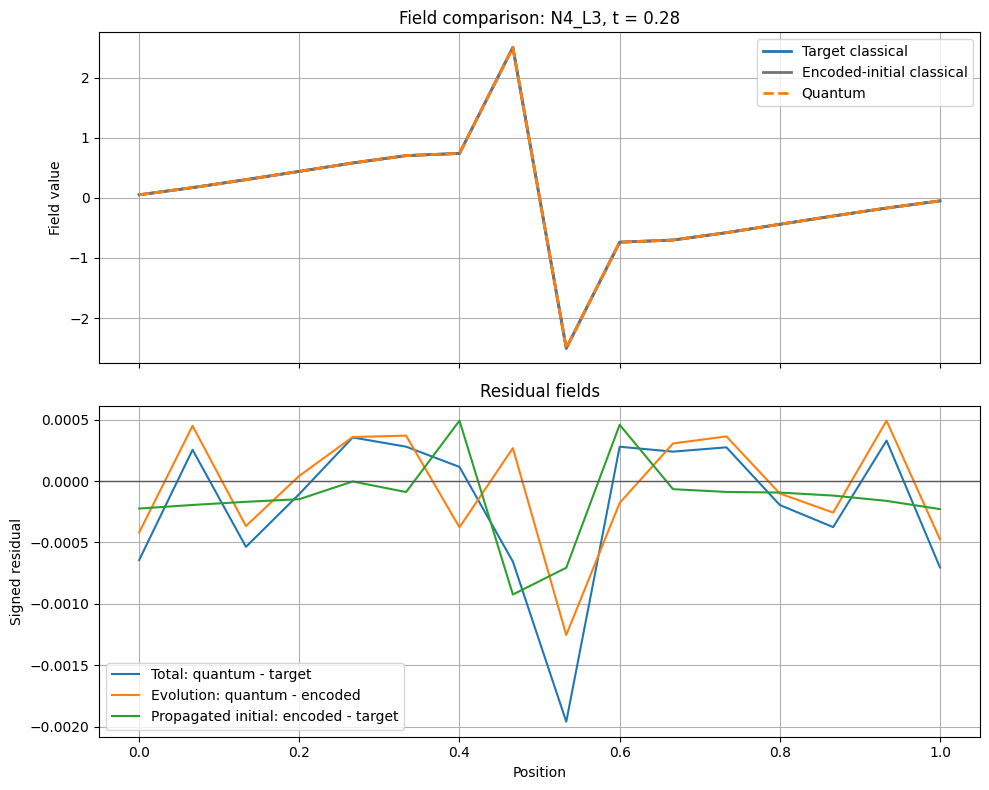

In [153]:
ERROR_TIMESTEP = -1
FINAL_ERROR_FIGSIZE = (10, 8)

final_error_comparison, final_error_axes, final_error_fig = an.plot_final_error_diagnostics(
    run,
    timestep=ERROR_TIMESTEP,
    figsize=FINAL_ERROR_FIGSIZE,
)
FINAL_ERROR_METRICS = [
    "timestep", "time", "RelativeL2Error", "EvolutionRelativeL2Error",
    "PropagatedInitialRelativeL2Error", "RelativeDerivativeL2Error",
    "RelativeLinfError",
]
pd.Series({key: final_error_comparison[key] for key in FINAL_ERROR_METRICS})


In [ ]:
# error_fig.savefig(f"figures/single_runs/error_evolution_{DIR_LABEL}_{LABEL}.pdf", bbox_inches="tight")
# final_error_fig.savefig(f"figures/single_runs/error_final_{DIR_LABEL}_{LABEL}.pdf", bbox_inches="tight")


## Expressibility and entangling capability

Expressibility is displayed as the saved KL divergence $D_{KL}$. Lower values mean that the circuit's fidelity distribution is closer to the Haar reference and therefore more expressive.


In [ ]:
# Add (dir_label, label) pairs here. These select independently saved *_expr results.
# With an empty selection, discover *_expr results and full runs containing either metric.
# Expressibility is the saved KL divergence, so lower is better.
EXPR_ENTCAP_SELECTION = []
EXPR_ENTCAP_FIGSIZE = None  # e.g. (12, 4); None uses the function default

if EXPR_ENTCAP_SELECTION:
    expr_runs = an.load_expr_runs(EXPR_ENTCAP_SELECTION)
else:
    expr_runs = an.discover_expr_runs(include_full_runs=True)

if expr_runs:
    an.plot_expr_entcap_vs_l(
        expr_runs, n_filter=None, figsize=EXPR_ENTCAP_FIGSIZE
    )
else:
    print("No selected runs contain expressibility or entangling-capability values.")


## Configurable multi-run comparison table

The table contains N, L, the number of circuit parameters, legacy variance, gradient-run variances, expressibility, entangling capability, circuit, initial state, and final-state comparison metrics. The `Expressibility` column is the saved KL divergence $D_{KL}$, for which lower values mean greater expressibility. `OverallGradientVariance` is the variance of the reconstructed total cost gradient, including the classical coefficients. `OverlapGradientVariance`, `AdvectionGradientVariance`, and `DiffusionGradientVariance` are calculated from the unscaled quantum combinations $dc_1$, $dc_4-dc_5$, and $dc_2-2dc_1+dc_3$, respectively. `Circuit1GradientVariance` through `Circuit5GradientVariance` are the variances of the five individual circuit derivatives $dc_1$ through $dc_5$. Gradient runs are matched exactly by `(N, L, Circuit, InitialState)`. Independently saved `exp_only` results are matched by `(N, L, Circuit)` and take priority over expressibility or entangling-capability values embedded in full simulation runs.

`InitialRelativeL2Error` measures the initial fit, `PropagatedInitialRelativeL2Error` compares the two classical trajectories initialized from the target and encoded fields, `EvolutionRelativeL2Error` compares the variational field with the classical trajectory initialized from the encoded field, and the existing `RelativeL2Error` is the total end-to-end error. These three final-time errors use the target classical field norm as their common denominator. Field derivatives use the simulation's periodic centered difference and mass uses $M=\Delta x\sum_i u_i$. Relative mass values are `NaN` when their reference mass is effectively zero. Leave `RUN_SELECTION` empty to select every available non-gradient simulation run with saved parameters.

Older manifests do not record a circuit name, so they are shown as `default`. Use `CIRCUIT_OVERRIDES` for older runs whose circuit is known from their label or experiment notes.


In [74]:
RUN_SELECTION = [
    # ("N3_mps_staircase", "L1"),
    # ("N4_mps_staircase", "L1"),
    # ("N3_mps_staircase", "L2"),
    # ("N4_mps_staircase", "L2"),
    # ("N3_mps_staircase_light", "L1"),
    # ("N4_mps_staircase_light", "L1"),
    # ("N3_mps_staircase_light", "L2"),
    # ("N4_mps_staircase_light", "L2"),
]

# Optional explicit variance selection. Leave empty to use all discovered variance runs.
VARIANCE_SELECTION = []

# Optional explicit gradient selection. Leave empty to use all discovered gradient runs.
GRADIENT_SELECTION = []

# Example: {"experiment_uni2_N4L3": "uni2"}
CIRCUIT_OVERRIDES = {}

selected_runs = an.load_runs(RUN_SELECTION) if RUN_SELECTION else an.discover_simulation_runs()
variance_runs = (
    [an.load_variance_run(d, label) for d, label in VARIANCE_SELECTION]
    if VARIANCE_SELECTION
    else an.discover_variance_runs()
)
gradient_runs = (
    [an.load_gradient_run(d, label) for d, label in GRADIENT_SELECTION]
    if GRADIENT_SELECTION
    else an.discover_gradient_runs()
)
expression_runs = an.discover_expr_runs(include_full_runs=False)

run_table = an.build_run_table(
    selected_runs,
    variance_runs=variance_runs,
    circuit_overrides=CIRCUIT_OVERRIDES,
    gradient_runs=gradient_runs,
    expression_runs=expression_runs,
)
# run_table


/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:1293: RuntimeWarning: overflow encountered in multiply
  - (dt / (2 * dx)) * previous * (right - left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:1292: RuntimeWarning: invalid value encountered in subtract
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:1292: RuntimeWarning: invalid value encountered in add
  + (mu * dt / dx**2) * (right - 2 * previous + left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:1291: RuntimeWarning: invalid value encountered in add
  previous
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:1293: RuntimeWarning: invalid value encountered in subtract
  - (dt / (2 * dx)) * previous * (right - left)
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:1291: RuntimeWarning: invalid value encountered in subtract
  previous
/Users/joel/Documents/MA/Code/VQCFD_quimb/analysis.py:1292: RuntimeWarning: overflow encountered in multi

In [10]:
NS = (3, 4, 5, 6)
UNI2_LAYERS = (1, 2, 3)

# N6 UNI2 has not been generated yet.
UNI2_NS = (3, 4, 5)
# UNI2_NS = NS  # Use after generating N6 UNI2 L1–L3.

# Optional explicit variance selection. Leave empty to use all discovered variance runs.
VARIANCE_SELECTION = []

# Optional explicit gradient selection. Leave empty to use all discovered gradient runs.
GRADIENT_SELECTION = []

# Example: {"experiment_uni2_N4L3": "uni2"}
CIRCUIT_OVERRIDES = {}

RUN_SELECTION = [
    # UNI2 reference cases: L1, L2, L3
    *[
        (f"N{n}_uni2", f"L{l}")
        for n in UNI2_NS
        for l in UNI2_LAYERS
    ],

    # Local RY-RZ has the same parameter formula as UNI2
    *[
        (f"N{n}_local_ry_rz", f"L{l}")
        for n in NS
        for l in UNI2_LAYERS
    ],

    # GHZ L2, L3, L4 match UNI2 L1, L2, L3
    *[
        (f"N{n}_ghz_orbit", f"L{l + 1}")
        for n in NS
        for l in UNI2_LAYERS
    ],

    # Multiscale L3, L5, L7 match UNI2 L1, L2, L3
    *[
        (f"N{n}_multiscale_tree", f"L{2 * l + 1}")
        for n in NS
        for l in UNI2_LAYERS
    ],

    # Default L3, L5, L7 match UNI2 L1, L2, L3
    *[
        (f"N{n}", f"L{2 * l + 1}")
        for n in NS
        for l in UNI2_LAYERS
    ],

    # Optional brickwork: comment out this whole expansion if unwanted
    # *[
    #     (f"N{n}_brickwork_ring_ry", f"L{2 * l + 1}")
    #     for n in NS
    #     for l in UNI2_LAYERS
    # ],
]

selected_runs = an.load_runs(RUN_SELECTION) if RUN_SELECTION else an.discover_simulation_runs()
variance_runs = (
    [an.load_variance_run(d, label) for d, label in VARIANCE_SELECTION]
    if VARIANCE_SELECTION
    else an.discover_variance_runs()
)
gradient_runs = (
    [an.load_gradient_run(d, label) for d, label in GRADIENT_SELECTION]
    if GRADIENT_SELECTION
    else an.discover_gradient_runs()
)
expression_runs = an.discover_expr_runs(include_full_runs=False)

run_table = an.build_run_table(
    selected_runs,
    variance_runs=variance_runs,
    circuit_overrides=CIRCUIT_OVERRIDES,
    gradient_runs=gradient_runs,
    expression_runs=expression_runs,
)

In [ ]:
run_table

### `run_table` values and available filters

Every column below is available to `plot_run_table` as `X` or `Y`. Any column can also be used in `FILTERS`, and columns can be used for `GROUP_BY` when grouping by that value is meaningful. A filter value can be one allowed value or a list/tuple/set of allowed values; different filters are combined with logical AND. Use an empty dictionary for no filtering.

`X_LABEL` and `Y_LABEL` override the axis labels. `SERIES_LABELS` optionally replaces the complete legend label for every plotted line or scatter series. Its order follows the plotting loops: all groups for the first `Y` column, followed by all groups for the next `Y` column. Leave it as `None` to use automatic labels.

- **Run configuration:** `Run` (saved-run label), `N` (number of qubits), `L` (number of ansatz layers), `NumberOfParameters`, `Circuit`, `InitialState`, and `OptimizationMode`.
- **Optimization effort:** `OptimizationTimesteps` is the number of evolved timesteps with a saved optimizer history. `TotalOptimizationSteps`, `MeanOptimizationSteps`, `MedianOptimizationSteps`, and `MaxOptimizationSteps` summarize the history lengths across those timesteps. For custom Adam modes these are parameter-update iterations (the saved initial cost is excluded); for noise-free Quimb/SciPy and COBYLA runs the old files only preserve loss-function evaluations, not the optimizer's exact internal iteration count. Compare these values only within a common `OptimizationMode`.
- **Variance data:** `Var` (legacy saved cost-gradient variance); `OverallGradientVariance` (reconstructed total cost-gradient variance); `OverlapGradientVariance` ($\operatorname{Var}(dc_1)$); `AdvectionGradientVariance` ($\operatorname{Var}(dc_4-dc_5)$); `DiffusionGradientVariance` ($\operatorname{Var}(dc_2-2dc_1+dc_3)$); and the five individual-circuit values `Circuit1GradientVariance`, `Circuit2GradientVariance`, `Circuit3GradientVariance`, `Circuit4GradientVariance`, and `Circuit5GradientVariance`, corresponding to $\operatorname{Var}(dc_1)$ through $\operatorname{Var}(dc_5)$.
- **Circuit characteristics:** `Expressibility` is the saved KL divergence $D_{KL}$ (lower is better); `EntanglingCapability` is unchanged.
- **Final-state comparisons:** `R2`, `Fidelity`, `MSE`, `RelativeL1Error`, `InitialRelativeL2Error`, `PropagatedInitialRelativeL2Error`, `EvolutionRelativeL2Error`, `RelativeL2Error`, `RelativeLinfError`, `RelativeDerivativeL2Error`, `RelativeDerivativeLinfError`, `RelativeMassError`, and `NormalizedMassDrift`.

**Initial states available in the discovered saved simulation runs:** `mixed_sine_modes`, `positive_periodic_wave`, `sine`, and `tapered_gaussian`.

**Circuits available in the discovered saved simulation runs:** `all_to_all_crx`, `block_crx`, `brickwork_ring_ry`, `default`, `ghz_orbit`, `local_ry_rz`, `multiscale_tree`, `ring_ry_rz`, `ring_trainable_crx`, `ring_trainable_crz`, and `uni2`.

The variance columns from gradient runs are `NaN` when no gradient run matches a table row's exact `(N, L, Circuit, InitialState)` configuration. To inspect the choices present after changing `RUN_SELECTION`, use `sorted(run_table["Circuit"].dropna().unique())` and `sorted(run_table["InitialState"].dropna().unique())`.


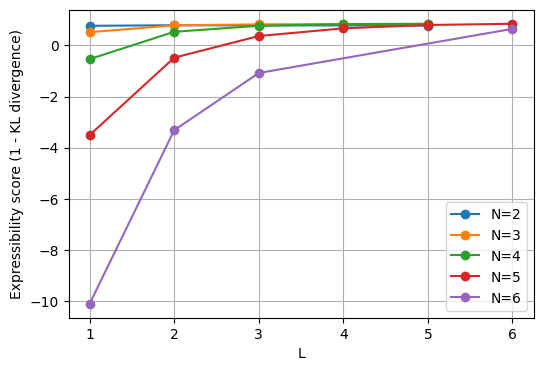

In [10]:
# X accepts one column; Y accepts one column or a list of columns.
# GROUP_BY accepts one column, a list of columns, or None.
X = "L"
Y = "Expressibility"  # e.g. "MeanOptimizationSteps" or a list of columns
GROUP_BY = ["N",]
FILTERS = {
    # "N": 4,
    "Circuit": ["paper_viscid"],
    #"NumberOfParameters": [32],
    "InitialState" : "sine",
}
PLOT_KIND = "line"       # "line" or "scatter"
LOG_Y = False
X_LABEL = None             # e.g. "Number of parameters"; None uses X
Y_LABEL = None             # e.g. "Expressibility (KL divergence)"; None uses Y
SERIES_LABELS = None       # e.g. ["Default", "GHZ", "Local", "Tree", "UNI2"]
X_LIMITS = None            # e.g. (0, 50); use None for automatic limits
Y_LIMITS = None            # e.g. (0, 0.4); use None for automatic limits
PLOT_SIZE = (6, 4)          # width, height in inches

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    filters=FILTERS,
    group_by=GROUP_BY,
    kind=PLOT_KIND,
    log_y=LOG_Y,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    series_labels=SERIES_LABELS,
    x_limits=X_LIMITS,
    y_limits=Y_LIMITS,
    figsize=PLOT_SIZE,
)
# filtered_table


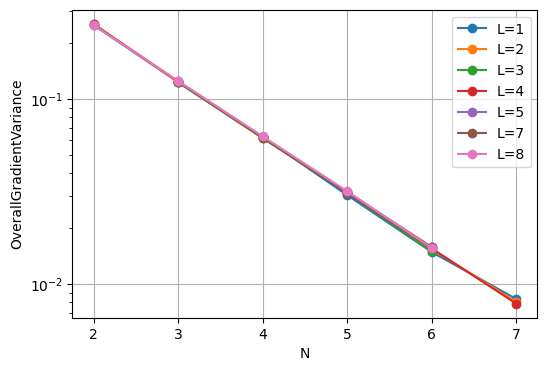

In [166]:
# X accepts one column; Y accepts one column or a list of columns.
# GROUP_BY accepts one column, a list of columns, or None.
X = "N"
Y = "OverallGradientVariance"  # e.g. "MeanOptimizationSteps" or a list of columns
GROUP_BY = ["L",]
FILTERS = {
    # "N": 4,
    "Circuit": ["default"],
    #"NumberOfParameters": [32],
    "InitialState" : "sine",
}
PLOT_KIND = "line"       # "line" or "scatter"
LOG_Y = True
X_LABEL = None             # e.g. "Number of parameters"; None uses X
Y_LABEL = None             # e.g. "Expressibility (KL divergence)"; None uses Y
SERIES_LABELS = None       # e.g. ["Default", "GHZ", "Local", "Tree", "UNI2"]
X_LIMITS = None            # e.g. (0, 50); use None for automatic limits
Y_LIMITS = None            # e.g. (0, 0.4); use None for automatic limits
PLOT_SIZE = (6, 4)          # width, height in inches

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    filters=FILTERS,
    group_by=GROUP_BY,
    kind=PLOT_KIND,
    log_y=LOG_Y,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    series_labels=SERIES_LABELS,
    x_limits=X_LIMITS,
    y_limits=Y_LIMITS,
    figsize=PLOT_SIZE,
)

In [ ]:
# folder = "errors"
# name = "errors_vs_L_default_pos"
# fig.savefig(f"figures/{folder}/{name}.pdf", bbox_inches='tight')

In [ ]:
# This second configurable plot uses the same general interface.
X = "L"
Y = "EntanglingCapability"
GROUP_BY = ["N",]
FILTERS = {
    # "N": [3],
    "Circuit": "default",
    "InitialState": "sine",
    # "L": [1, 2, 3],
}
PLOT_KIND = "line"       # "line" or "scatter"
LOG_Y = False
X_LABEL = None             # e.g. "Number of qubits"; None uses X
Y_LABEL = None             # e.g. "Gradient variance"; None uses Y
SERIES_LABELS = None       # e.g. ["Sine", "Gaussian"]
X_LIMITS = None            # e.g. (2, 6); use None for automatic limits
Y_LIMITS = None            # e.g. (1e-8, 1); use None for automatic limits
PLOT_SIZE = (6, 4)          # width, height in inches

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    filters=FILTERS,
    group_by=GROUP_BY,
    kind=PLOT_KIND,
    log_y=LOG_Y,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    series_labels=SERIES_LABELS,
    x_limits=X_LIMITS,
    y_limits=Y_LIMITS,
    figsize=PLOT_SIZE,
)

In [ ]:
# folder = "exprs"
# name = "entcap_default_default_all"
# fig.savefig(f"figures/{folder}/{name}.pdf", bbox_inches='tight')

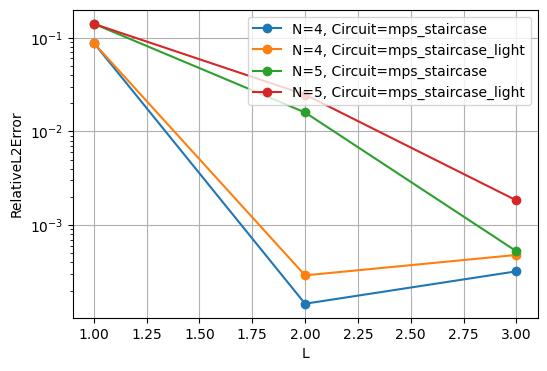

In [114]:
# This second configurable plot uses the same general interface.
# Expressibility is the saved KL divergence, so lower is better.
X = "L"
Y = "RelativeL2Error"
GROUP_BY = ["N","Circuit"]
FILTERS = {
    "N": [4,5],
    "Circuit": ["mps_staircase","mps_staircase_light"],
    # "L": [1, 2, 3],
    "InitialState": "sine",
}
PLOT_KIND = "line"       # "line" or "scatter"
LOG_Y = True
X_LABEL = None             # e.g. "Number of qubits"; None uses X
Y_LABEL = None             # e.g. "Gradient variance"; None uses Y
SERIES_LABELS = None       # e.g. ["Sine", "Gaussian"]
X_LIMITS = None            # e.g. (2, 6); use None for automatic limits
Y_LIMITS = None            # e.g. (1e-8, 1); use None for automatic limits
PLOT_SIZE = (6, 4)          # width, height in inches

filtered_table, ax, fig = an.plot_run_table(
    run_table,
    x=X,
    y=Y,
    filters=FILTERS,
    group_by=GROUP_BY,
    kind=PLOT_KIND,
    log_y=LOG_Y,
    x_label=X_LABEL,
    y_label=Y_LABEL,
    series_labels=SERIES_LABELS,
    x_limits=X_LIMITS,
    y_limits=Y_LIMITS,
    figsize=PLOT_SIZE,
)

## Thesis-ready custom table

Choose run labels from `run_table["Run"]` and values from `run_table.columns`. Both lists preserve the exact order in which you write them: the first selected run becomes the first row and the first selected value becomes the first column. Leave `TABLE_RUNS` empty to use every current row, or `TABLE_VALUES` empty to use every `run_table` column. Run labels are used only for selection and are not displayed unless you explicitly include `"Run"` in `TABLE_VALUES`.

Use `TABLE_COLUMN_LABELS` to replace all displayed column headings in order. `TABLE_EXTRA_VALUES` entries have the form `(row_number, source_run, value_name)`, with 1-based output row numbers. Each row's first assignment shares the first extra column, its second assignment shares the second extra column, and so on; missing positions are left blank. The first cell displays the selected data as a styled notebook table. The following cell generates copy-ready LaTeX; it escapes underscores and uses `--` for missing values. The generated table uses the `booktabs` commands, so the thesis preamble should include `\usepackage{booktabs}`.

In [ ]:
# Use the full labels shown by: run_table["Run"].tolist()
TABLE_RUNS = [
    "N3_uni2_L1",
    "N3_local_ry_rz_L1",
    "N3_ghz_orbit_L2",
    "N3_multiscale_tree_L3",
    "N3_L3",
    "N3_paper_viscid_L3"
]

# Every name in run_table.columns is accepted, in the order given here.
TABLE_VALUES = [
    "Circuit",
    "N",
    "L",
    "NumberOfParameters",
    "Expressibility",
    "EntanglingCapability",
    "RelativeL2Error",
    "MeanOptimizationSteps"
]

# Optional display headings for every regular and extra column, in output order.
# Leave empty to use the run_table names and "Extra" / "Extra 1", "Extra 2", ...
TABLE_COLUMN_LABELS = [
    # "Qubits", "Layers", "Parameters", "Expressibility",
    # "Entangling capability", "Relative L2 error", "Extra",
]

# (output row number, source run label, source run_table value).
# Row numbers are 1-based. Add multiple entries for a row to create further Extra columns.
TABLE_EXTRA_VALUES = [
    # (1, "N3_L4", "RelativeL2Error"),
    # (2, "N3_uni2_L2_mixed_sine_modes", "EvolutionRelativeL2Error"),
]
TABLE_PRECISION = 4  # Significant digits used only for presentation

selected_run_labels = list(TABLE_RUNS) or run_table["Run"].tolist()
selected_values = list(TABLE_VALUES) or run_table.columns.tolist()

duplicate_run_labels = (
    run_table.loc[run_table["Run"].duplicated(keep=False), "Run"]
    .drop_duplicates()
    .tolist()
)
if duplicate_run_labels:
    raise ValueError(
        "The Run column must uniquely identify rows, but these labels are duplicated: "
        f"{duplicate_run_labels}"
    )

missing_runs = [
    label for label in selected_run_labels if label not in set(run_table["Run"])
]
missing_values = [value for value in selected_values if value not in run_table.columns]
if missing_runs:
    raise KeyError(
        f"Unknown TABLE_RUNS labels: {missing_runs}. "
        'Inspect the choices with run_table["Run"].tolist().'
    )
if missing_values:
    raise KeyError(
        f"Unknown TABLE_VALUES columns: {missing_values}. "
        "Inspect the choices with run_table.columns.tolist()."
    )
if not selected_run_labels:
    raise ValueError("run_table is empty; build it before creating the custom table.")

table_by_run = run_table.set_index("Run", drop=False)
thesis_table = (
    table_by_run.loc[selected_run_labels, selected_values]
    .copy()
    .reset_index(drop=True)
)

# Collect each row's extras in the order in which they occur in TABLE_EXTRA_VALUES.
extra_values_by_row = [[] for _ in range(len(thesis_table))]
for assignment_number, assignment in enumerate(TABLE_EXTRA_VALUES, start=1):
    if not isinstance(assignment, (tuple, list)) or len(assignment) != 3:
        raise ValueError(
            f"TABLE_EXTRA_VALUES entry {assignment_number} must be "
            "(row_number, run_label, value_name)."
        )
    row_number, source_run, value_name = assignment
    if (
        isinstance(row_number, (bool, np.bool_))
        or not isinstance(row_number, (int, np.integer))
        or not 1 <= int(row_number) <= len(thesis_table)
    ):
        raise IndexError(
            f"TABLE_EXTRA_VALUES entry {assignment_number} uses row {row_number!r}; "
            f"choose a 1-based row from 1 to {len(thesis_table)}."
        )
    if source_run not in table_by_run.index:
        raise KeyError(
            f"TABLE_EXTRA_VALUES entry {assignment_number} uses unknown run "
            f"{source_run!r}."
        )
    if value_name not in run_table.columns:
        raise KeyError(
            f"TABLE_EXTRA_VALUES entry {assignment_number} uses unknown value "
            f"{value_name!r}."
        )
    extra_values_by_row[int(row_number) - 1].append(
        table_by_run.at[source_run, value_name]
    )

max_extra_values = max((len(values) for values in extra_values_by_row), default=0)
for extra_index in range(max_extra_values):
    thesis_table[f"__extra_{extra_index + 1}__"] = [
        values[extra_index] if extra_index < len(values) else np.nan
        for values in extra_values_by_row
    ]

if max_extra_values == 1:
    default_extra_labels = ["Extra"]
else:
    default_extra_labels = [
        f"Extra {extra_index}" for extra_index in range(1, max_extra_values + 1)
    ]
default_column_labels = [*selected_values, *default_extra_labels]
column_labels = list(TABLE_COLUMN_LABELS) or default_column_labels
if len(column_labels) != len(thesis_table.columns):
    raise ValueError(
        f"TABLE_COLUMN_LABELS contains {len(column_labels)} labels, but the table has "
        f"{len(thesis_table.columns)} columns after adding extras."
    )
thesis_table.columns = column_labels

from IPython.display import HTML, display

thesis_table_html = thesis_table.to_html(
    border=0,
    classes="thesis-run-table",
    index=False,
    justify="right",
    na_rep="—",
    float_format=lambda value: f"{value:.{TABLE_PRECISION}g}",
)
display(HTML(f"""
<style>
.thesis-table-wrap {{ display: inline-block; max-width: 100%; overflow-x: auto; }}
.thesis-table-caption {{ font-size: 1.1em; font-weight: 600; margin: 0 0 0.5em; }}
.thesis-run-table {{ border-collapse: collapse; font-size: 0.95em; }}
.thesis-run-table th, .thesis-run-table td {{ padding: 0.45em 0.75em; text-align: right; white-space: nowrap; }}
.thesis-run-table thead th {{ border-bottom: 2px solid currentColor; }}
.thesis-run-table tbody th, .thesis-run-table tbody td {{ border-bottom: 1px solid rgba(127, 127, 127, 0.35); }}
.thesis-run-table tbody tr:nth-child(even) {{ background: rgba(127, 127, 127, 0.08); }}
</style>
<div class="thesis-table-wrap">
  <div class="thesis-table-caption">Selected simulation runs</div>
  {thesis_table_html}
</div>
"""))

In [100]:
# Use the full labels shown by: run_table["Run"].tolist()
TABLE_RUNS = [
    # "N4_brickwork_ring_ry_L4",
    # "N4_L4",
    # "N4_multiscale_tree_L4",
    # "N4_paper_viscid_L3",
    # # "N4_mps_staircase_light_L1",
    # "N5_brickwork_ring_ry_L8",
    # "N5_L8",
    # # "N5_multiscale_tree_L8",
    # "N5_paper_viscid_L6",
    # "N5_mps_staircase_light_L2",
    "N4_brickwork_ring_ry_L8",
    "N4_L8",
    "N4_multiscale_tree_L8",
    "N4_paper_viscid_L6",
    "N4_mps_staircase_light_L2",
]

# Every name in run_table.columns is accepted, in the order given here.
TABLE_VALUES = [
    "Circuit",
    "N",
    "L",
    "NumberOfParameters",
    "Expressibility",
    "EntanglingCapability",
    "RelativeL2Error",
    # "MeanOptimizationSteps"
]

# Optional display headings for every regular and extra column, in output order.
# Leave empty to use the run_table names and "Extra" / "Extra 1", "Extra 2", ...
TABLE_COLUMN_LABELS = [
    # "Qubits", "Layers", "Parameters", "Expressibility",
    # "Entangling capability", "Relative L2 error", "Extra",
]

# (output row number, source run label, source run_table value).
# Row numbers are 1-based. Add multiple entries for a row to create further Extra columns.
TABLE_EXTRA_VALUES = [
    # (1, "N3_L4", "RelativeL2Error"),
    # (2, "N3_uni2_L2_mixed_sine_modes", "EvolutionRelativeL2Error"),
]
TABLE_PRECISION = 4  # Significant digits used only for presentation

selected_run_labels = list(TABLE_RUNS) or run_table["Run"].tolist()
selected_values = list(TABLE_VALUES) or run_table.columns.tolist()

duplicate_run_labels = (
    run_table.loc[run_table["Run"].duplicated(keep=False), "Run"]
    .drop_duplicates()
    .tolist()
)
if duplicate_run_labels:
    raise ValueError(
        "The Run column must uniquely identify rows, but these labels are duplicated: "
        f"{duplicate_run_labels}"
    )

missing_runs = [
    label for label in selected_run_labels if label not in set(run_table["Run"])
]
missing_values = [value for value in selected_values if value not in run_table.columns]
if missing_runs:
    raise KeyError(
        f"Unknown TABLE_RUNS labels: {missing_runs}. "
        'Inspect the choices with run_table["Run"].tolist().'
    )
if missing_values:
    raise KeyError(
        f"Unknown TABLE_VALUES columns: {missing_values}. "
        "Inspect the choices with run_table.columns.tolist()."
    )
if not selected_run_labels:
    raise ValueError("run_table is empty; build it before creating the custom table.")

table_by_run = run_table.set_index("Run", drop=False)
thesis_table = (
    table_by_run.loc[selected_run_labels, selected_values]
    .copy()
    .reset_index(drop=True)
)

# Collect each row's extras in the order in which they occur in TABLE_EXTRA_VALUES.
extra_values_by_row = [[] for _ in range(len(thesis_table))]
for assignment_number, assignment in enumerate(TABLE_EXTRA_VALUES, start=1):
    if not isinstance(assignment, (tuple, list)) or len(assignment) != 3:
        raise ValueError(
            f"TABLE_EXTRA_VALUES entry {assignment_number} must be "
            "(row_number, run_label, value_name)."
        )
    row_number, source_run, value_name = assignment
    if (
        isinstance(row_number, (bool, np.bool_))
        or not isinstance(row_number, (int, np.integer))
        or not 1 <= int(row_number) <= len(thesis_table)
    ):
        raise IndexError(
            f"TABLE_EXTRA_VALUES entry {assignment_number} uses row {row_number!r}; "
            f"choose a 1-based row from 1 to {len(thesis_table)}."
        )
    if source_run not in table_by_run.index:
        raise KeyError(
            f"TABLE_EXTRA_VALUES entry {assignment_number} uses unknown run "
            f"{source_run!r}."
        )
    if value_name not in run_table.columns:
        raise KeyError(
            f"TABLE_EXTRA_VALUES entry {assignment_number} uses unknown value "
            f"{value_name!r}."
        )
    extra_values_by_row[int(row_number) - 1].append(
        table_by_run.at[source_run, value_name]
    )

max_extra_values = max((len(values) for values in extra_values_by_row), default=0)
for extra_index in range(max_extra_values):
    thesis_table[f"__extra_{extra_index + 1}__"] = [
        values[extra_index] if extra_index < len(values) else np.nan
        for values in extra_values_by_row
    ]

if max_extra_values == 1:
    default_extra_labels = ["Extra"]
else:
    default_extra_labels = [
        f"Extra {extra_index}" for extra_index in range(1, max_extra_values + 1)
    ]
default_column_labels = [*selected_values, *default_extra_labels]
column_labels = list(TABLE_COLUMN_LABELS) or default_column_labels
if len(column_labels) != len(thesis_table.columns):
    raise ValueError(
        f"TABLE_COLUMN_LABELS contains {len(column_labels)} labels, but the table has "
        f"{len(thesis_table.columns)} columns after adding extras."
    )
thesis_table.columns = column_labels

from IPython.display import HTML, display

thesis_table_html = thesis_table.to_html(
    border=0,
    classes="thesis-run-table",
    index=False,
    justify="right",
    na_rep="—",
    float_format=lambda value: f"{value:.{TABLE_PRECISION}g}",
)
display(HTML(f"""
<style>
.thesis-table-wrap {{ display: inline-block; max-width: 100%; overflow-x: auto; }}
.thesis-table-caption {{ font-size: 1.1em; font-weight: 600; margin: 0 0 0.5em; }}
.thesis-run-table {{ border-collapse: collapse; font-size: 0.95em; }}
.thesis-run-table th, .thesis-run-table td {{ padding: 0.45em 0.75em; text-align: right; white-space: nowrap; }}
.thesis-run-table thead th {{ border-bottom: 2px solid currentColor; }}
.thesis-run-table tbody th, .thesis-run-table tbody td {{ border-bottom: 1px solid rgba(127, 127, 127, 0.35); }}
.thesis-run-table tbody tr:nth-child(even) {{ background: rgba(127, 127, 127, 0.08); }}
</style>
<div class="thesis-table-wrap">
  <div class="thesis-table-caption">Selected simulation runs</div>
  {thesis_table_html}
</div>
"""))

Circuit,N,L,NumberOfParameters,Expressibility,EntanglingCapability,RelativeL2Error
brickwork_ring_ry,4,8,36,0.1388,0.7744,0.0003763
default,4,8,36,0.1401,0.7717,6.994e-05
multiscale_tree,4,8,36,0.1406,0.7346,4.979e-05
paper_viscid,4,6,37,0.1443,0.7232,0.0008957
mps_staircase_light,4,2,38,0.1475,0.651,0.0002915


In [101]:
from IPython.display import Code, display

LATEX_CAPTION = "Selected simulation results"
LATEX_LABEL = "tab:selected-simulation-results"
LATEX_POSITION = "htbp"
LATEX_COLUMN_FORMAT = None  # e.g. "rrlll"; None infers numeric/right and text/left

_LATEX_ESCAPES = {
    "\\": r"\textbackslash{}",
    "&": r"\&",
    "%": r"\%",
    "$": r"\$",
    "#": r"\#",
    "_": r"\_",
    "{": r"\{",
    "}": r"\}",
    "~": r"\textasciitilde{}",
    "^": r"\textasciicircum{}",
    "\n": " ",
}

def _latex_escape(value):
    return "".join(_LATEX_ESCAPES.get(character, character) for character in str(value))

def _latex_value(value):
    if pd.isna(value):
        return "--"
    if isinstance(value, (float, np.floating)):
        return f"{value:.{TABLE_PRECISION}g}"
    return _latex_escape(value)

column_format = LATEX_COLUMN_FORMAT or "".join(
    "r" if pd.api.types.is_numeric_dtype(thesis_table.iloc[:, column_index]) else "l"
    for column_index in range(len(thesis_table.columns))
)
header = [_latex_escape(column) for column in thesis_table.columns]
latex_lines = [
    rf"\begin{{table}}[{LATEX_POSITION}]",
    r"\centering",
]
if LATEX_CAPTION:
    latex_lines.append(rf"\caption{{{_latex_escape(LATEX_CAPTION)}}}")
if LATEX_LABEL:
    latex_lines.append(rf"\label{{{LATEX_LABEL}}}")
latex_lines.extend([
    rf"\begin{{tabular}}{{{column_format}}}",
    r"\toprule",
    " & ".join(header) + r" \\",
    r"\midrule",
])
for row in thesis_table.itertuples(index=False, name=None):
    latex_lines.append(
        " & ".join(_latex_value(value) for value in row)
        + r" \\"
    )
latex_lines.extend([
    r"\bottomrule",
    r"\end{tabular}",
    r"\end{table}",
])
latex_table = "\n".join(latex_lines)
display(Code(latex_table, language="latex"))

\begin{table}[htbp]
\centering
\caption{Selected simulation results}
\label{tab:selected-simulation-results}
\begin{tabular}{lrrrrrr}
\toprule
Circuit & N & L & NumberOfParameters & Expressibility & EntanglingCapability & RelativeL2Error \\
\midrule
brickwork\_ring\_ry & 4 & 8 & 36 & 0.1388 & 0.7744 & 0.0003763 \\
default & 4 & 8 & 36 & 0.1401 & 0.7717 & 6.994e-05 \\
multiscale\_tree & 4 & 8 & 36 & 0.1406 & 0.7346 & 4.979e-05 \\
paper\_viscid & 4 & 6 & 37 & 0.1443 & 0.7232 & 0.0008957 \\
mps\_staircase\_light & 4 & 2 & 38 & 0.1475 & 0.651 & 0.0002915 \\
\bottomrule
\end{tabular}
\end{table}

In [113]:
run_table.columns

Index(['Run', 'N', 'L', 'NumberOfParameters', 'OptimizationMode',
       'OptimizationTimesteps', 'TotalOptimizationSteps',
       'MeanOptimizationSteps', 'MedianOptimizationSteps',
       'MaxOptimizationSteps', 'Var', 'OverallGradientVariance',
       'OverlapGradientVariance', 'AdvectionGradientVariance',
       'DiffusionGradientVariance', 'Circuit1GradientVariance',
       'Circuit2GradientVariance', 'Circuit3GradientVariance',
       'Circuit4GradientVariance', 'Circuit5GradientVariance',
       'Expressibility', 'EntanglingCapability', 'Circuit', 'InitialState',
       'R2', 'Fidelity', 'MSE', 'RelativeL1Error', 'InitialRelativeL2Error',
       'PropagatedInitialRelativeL2Error', 'EvolutionRelativeL2Error',
       'RelativeL2Error', 'RelativeLinfError', 'RelativeDerivativeL2Error',
       'RelativeDerivativeLinfError', 'RelativeMassError',
       'NormalizedMassDrift'],
      dtype='str')